# Model Testing and Benchmarking

This notebook is used to inspect the datasets and evaluate the trained SigLIP-based detector. The main aim is to first check performance on the held-out OpenFake test data and then test the same trained model on a separate benchmark dataset. This gives an indication of whether the detector is learning features that transfer beyond the dataset used during training.


In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path
from PIL import Image, ImageEnhance, ImageFilter
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report
from transformers import AutoProcessor, AutoModel
from tqdm import tqdm
import io
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
import pandas as pd

## Loading the OpenFake dataset

The OpenFake subset is used as the main dataset for the trained detector. The metadata file is loaded first so that the class labels, generator information and image paths can be inspected before running the evaluation.


In [2]:
DATA_ROOT = "/kaggle/input/datasets/nishant2015/openfake50k/kaggle/working/openfake_subset"

In [3]:
df=pd.read_csv(DATA_ROOT+"/metadata.csv")

## Dataset inspection

Before testing the model, I carried out some basic inspection of both datasets. Representative real and AI-generated images are displayed to check that the files are being read correctly. I also looked at the distribution of image generators in OpenFake and in the external benchmark.

The generator names are normalised later in this section so that the two datasets can be compared more consistently. This was useful for checking whether some generators in the benchmark were already represented in the training dataset and which generators were genuinely different.


Real path: /kaggle/input/datasets/nishant2015/openfake50k/kaggle/working/openfake_subset/real/real_023700.jpg
Exists: True
Fake path: /kaggle/input/datasets/nishant2015/openfake50k/kaggle/working/openfake_subset/fake/fake_006574.jpg
Exists: True


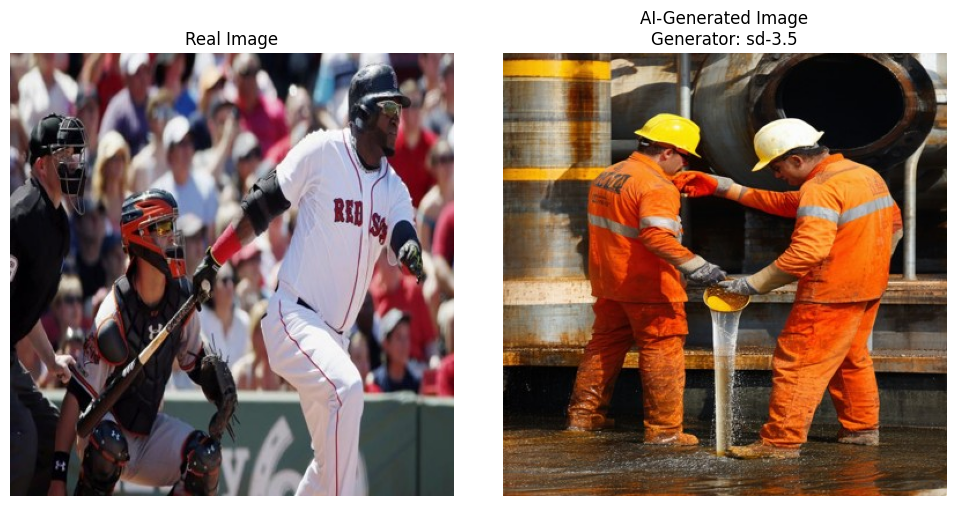

In [4]:
import pandas as pd
import os
from PIL import Image
import matplotlib.pyplot as plt

DATA_ROOT = "/kaggle/input/datasets/nishant2015/openfake50k/kaggle/working/openfake_subset"

df = pd.read_csv(os.path.join(DATA_ROOT, "metadata.csv"))

real_row = df[df["label"] == "real"].sample(
    1, random_state=25
).iloc[0]

fake_row = df[df["label"] == "fake"].sample(
    1, random_state=999
).iloc[0]


def fix_path(old_path):
    filename = os.path.basename(old_path)

    if "/real/" in old_path:
        return os.path.join(DATA_ROOT, "real", filename)

    elif "/fake/" in old_path:
        return os.path.join(DATA_ROOT, "fake", filename)

    else:
        raise ValueError(f"Could not determine image folder: {old_path}")


real_path = fix_path(real_row["path"])
fake_path = fix_path(fake_row["path"])

print("Real path:", real_path)
print("Exists:", os.path.exists(real_path))

print("Fake path:", fake_path)
print("Exists:", os.path.exists(fake_path))


real_image = Image.open(real_path).convert("RGB")
fake_image = Image.open(fake_path).convert("RGB")


fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(real_image)
axes[0].set_title("Real Image")
axes[0].axis("off")

axes[1].imshow(fake_image)

if "model" in df.columns:
    axes[1].set_title(
        f"AI-Generated Image\nGenerator: {fake_row['model']}"
    )
else:
    axes[1].set_title("AI-Generated Image")

axes[1].axis("off")

plt.tight_layout()

plt.savefig(
    "/kaggle/working/real_vs_ai_generated_example.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Real images found: 1020
AI images found: 1018

Selected real image:
/kaggle/input/datasets/nishant2015/aiimagebenchmarkdataset/benchmark-v0.1/images/real/product/product_045_00y8k1-0DlA.jpg

Selected AI image:
/kaggle/input/datasets/nishant2015/aiimagebenchmarkdataset/benchmark-v0.1/images/ai/food/flux_2_flex_food_02.png


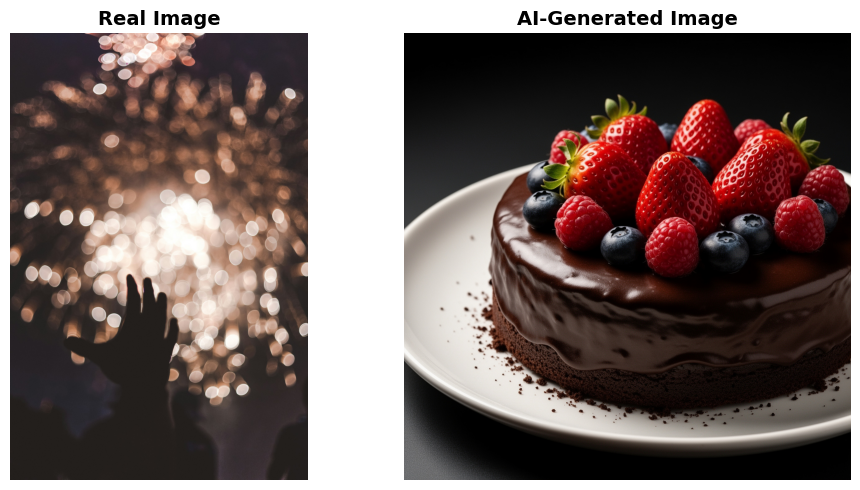

In [5]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt


AI_DIR = (
    "/kaggle/input/datasets/nishant2015/"
    "aiimagebenchmarkdataset/benchmark-v0.1/images/ai"
)

REAL_DIR = (
    "/kaggle/input/datasets/nishant2015/"
    "aiimagebenchmarkdataset/benchmark-v0.1/images/real"
)


valid_extensions = (
    ".jpg",
    ".jpeg",
    ".png",
    ".webp",
    ".bmp",
    ".tif",
    ".tiff"
)

def find_images(folder):
    image_paths = []

    for root, dirs, files in os.walk(folder):
        for file in files:
            if file.lower().endswith(valid_extensions):
                image_paths.append(
                    os.path.join(root, file)
                )

    return image_paths


real_files = find_images(REAL_DIR)
ai_files = find_images(AI_DIR)

print("Real images found:", len(real_files))
print("AI images found:", len(ai_files))


if len(real_files) == 0:
    raise ValueError(
        f"No real images found inside:\n{REAL_DIR}"
    )

if len(ai_files) == 0:
    raise ValueError(
        f"No AI images found inside:\n{AI_DIR}"
    )


random.seed(25)
real_path = random.choice(real_files)

random.seed(999)
ai_path = random.choice(ai_files)

print("\nSelected real image:")
print(real_path)

print("\nSelected AI image:")
print(ai_path)


real_image = Image.open(real_path).convert("RGB")
ai_image = Image.open(ai_path).convert("RGB")


fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(real_image)
axes[0].set_title(
    "Real Image",
    fontsize=14,
    fontweight="bold"
)
axes[0].axis("off")

axes[1].imshow(ai_image)
axes[1].set_title(
    "AI-Generated Image",
    fontsize=14,
    fontweight="bold"
)
axes[1].axis("off")

plt.tight_layout()

plt.savefig(
    "/kaggle/working/benchmark_real_vs_ai_example.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

model
sd-3.5               3110
sd-2.1               2851
flux.1-dev           2497
sdxl-epic-realism    1266
midjourney-6         1087
Name: count, dtype: int64


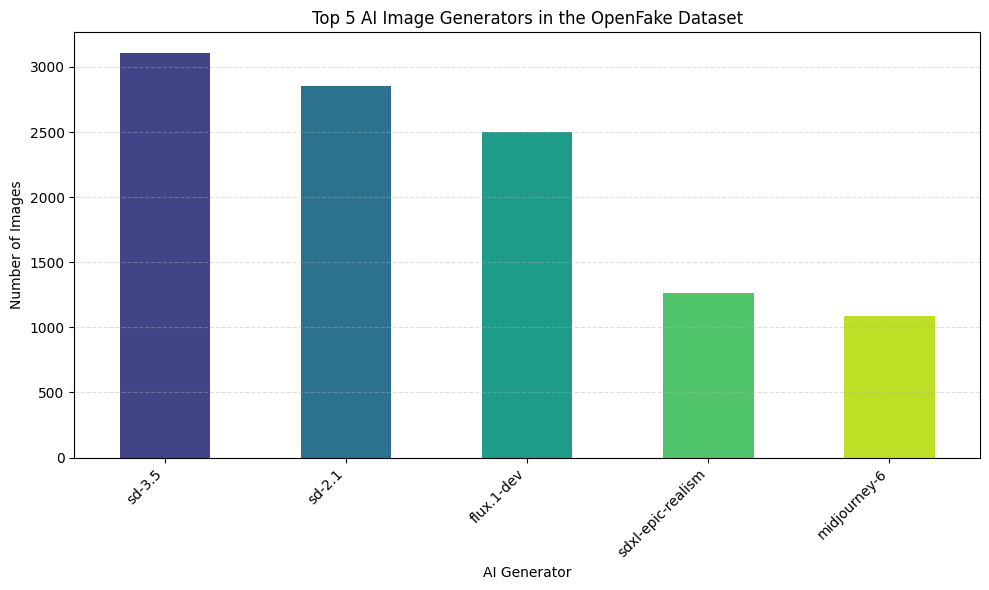

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv(
    "/kaggle/input/datasets/nishant2015/openfake50k/kaggle/working/openfake_subset/metadata.csv"
)

fake_df = df[df["label"] == "fake"]

generator_counts = (
    fake_df["model"]
    .value_counts()
    .sort_values(ascending=False)
    .head(5)
)

print(generator_counts)

colors = plt.cm.viridis(
    np.linspace(0.2, 0.9, len(generator_counts))
)

plt.figure(figsize=(10, 6))

generator_counts.plot(
    kind="bar",
    color=colors
)

plt.title("Top 5 AI Image Generators in the OpenFake Dataset")
plt.xlabel("AI Generator")
plt.ylabel("Number of Images")

plt.xticks(rotation=45, ha="right")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.savefig(
    "openfake_top5_generator_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Total AI-generated images: 1018

AI DETECTOR ARENA GENERATOR DISTRIBUTION
       generator  number_of_images  percentage
      hunyuan_v3                60        5.89
       qwen_2512                60        5.89
     seedream_v4                60        5.89
     seedream_v3                60        5.89
      recraft_v3                60        5.89
     grok_aurora                60        5.89
         z_image                60        5.89
    flux_schnell                60        5.89
       glm_image                60        5.89
   flux_pro_v1.1                60        5.89
     flux_2_flex                60        5.89
    gemini_3_pro                60        5.89
   gpt_image_1.5                60        5.89
        wan_v2.6                60        5.89
     ideogram_v3                60        5.89
    sd_3.5_large                60        5.89
leonardo_phoenix                58        5.70

Number of unique generators: 17
Total images accounted for: 1018


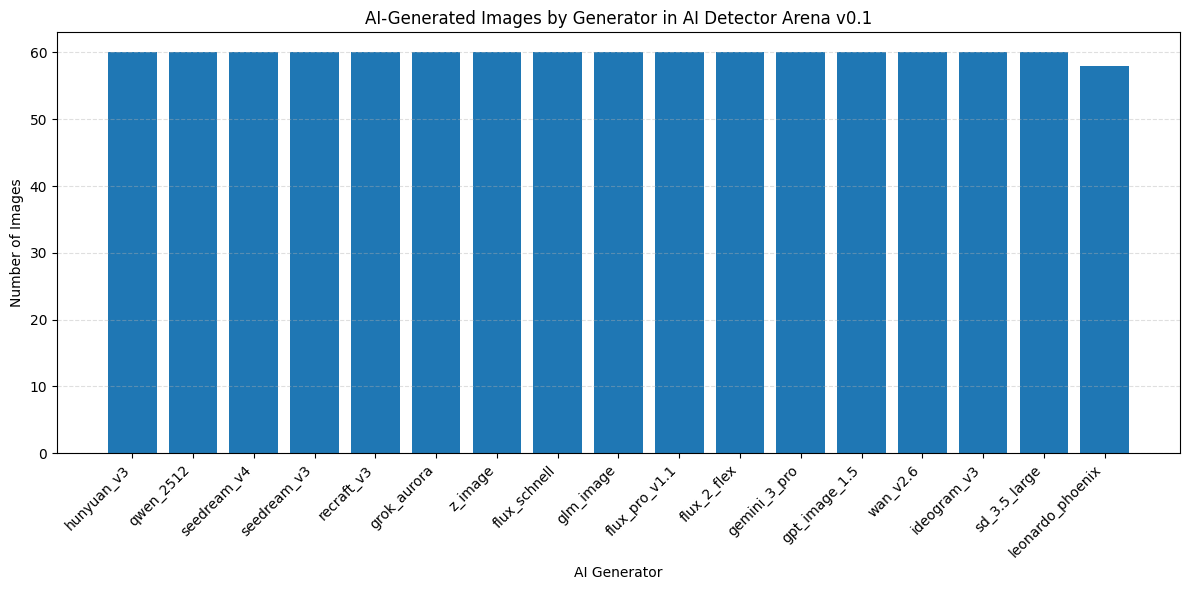

In [7]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


ARENA_FAKE_DIR = Path(
    "/kaggle/input/datasets/nishant2015/aiimagebenchmarkdataset/"
    "benchmark-v0.1/images/ai"
)


def extract_generator_name(img_path):
    """
    Example:
    flux_2_flex_landscape_01.png -> flux_2_flex
    flux_pro_v1.1_landscape_01.png -> flux_pro_v1.1
    """

    name = img_path.stem
    parts = name.split("_")

    if len(parts) > 2:
        return "_".join(parts[:-2])

    return "unknown"


extensions = ["*.jpg", "*.jpeg", "*.png", "*.webp"]

arena_paths = []

for ext in extensions:
    arena_paths.extend(ARENA_FAKE_DIR.rglob(ext))


print("Total AI-generated images:", len(arena_paths))


arena_df = pd.DataFrame({
    "image_path": [str(path) for path in arena_paths],
    "generator": [
        extract_generator_name(path)
        for path in arena_paths
    ]
})


generator_counts = (
    arena_df["generator"]
    .value_counts()
    .rename_axis("generator")
    .reset_index(name="number_of_images")
)

generator_counts["percentage"] = (
    generator_counts["number_of_images"]
    / len(arena_df)
    * 100
)

generator_counts["percentage"] = (
    generator_counts["percentage"].round(2)
)


print("\n" + "=" * 70)
print("AI DETECTOR ARENA GENERATOR DISTRIBUTION")
print("=" * 70)

print(
    generator_counts.to_string(
        index=False
    )
)

print("\nNumber of unique generators:",
      generator_counts["generator"].nunique())

print(
    "Total images accounted for:",
    generator_counts["number_of_images"].sum()
)


generator_counts.to_csv(
    "ai_detector_arena_generator_distribution.csv",
    index=False
)


plot_df = generator_counts.sort_values(
    "number_of_images",
    ascending=False
)

plt.figure(figsize=(12, 6))

plt.bar(
    plot_df["generator"],
    plot_df["number_of_images"]
)

plt.xlabel("AI Generator")
plt.ylabel("Number of Images")
plt.title(
    "AI-Generated Images by Generator in AI Detector Arena v0.1"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.savefig(
    "ai_detector_arena_generator_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [8]:
import pandas as pd
import re

df = pd.read_csv(
    "/kaggle/input/datasets/nishant2015/openfake50k/"
    "kaggle/working/openfake_subset/metadata.csv"
)

fake_df = df[df["label"] == "fake"].copy()


def normalize_name(name):
    if pd.isna(name):
        return None

    name = str(name).lower().strip()

    name = name.replace("_", " ")
    name = name.replace("-", " ")

    name = re.sub(r"\s+", " ", name)

    return name.strip()


fake_df["model_norm"] = fake_df["model"].apply(normalize_name)


models_to_check = [
    "flux 1.1 pro",
    "flux.1 schnell",
    "ideogram 3.0",
    "seedream v4.0",
    "seedream v4.5"
]


print("=" * 70)
print("OPENFAKE MODEL COUNTS")
print("=" * 70)

for model in models_to_check:

    matched = fake_df[fake_df["model_norm"] == model]

    print(f"\n{model}")
    print("Number of images:", len(matched))

    print("Raw model name(s):")
    print(matched["model"].value_counts().to_string())

OPENFAKE MODEL COUNTS

flux 1.1 pro
Number of images: 673
Raw model name(s):
model
flux-1.1-pro    673

flux.1 schnell
Number of images: 846
Raw model name(s):
model
flux.1-schnell    846

ideogram 3.0
Number of images: 591
Raw model name(s):
model
ideogram-3.0    591

seedream v4.0
Number of images: 54
Raw model name(s):
model
seedream-v4.0    54

seedream v4.5
Number of images: 56
Raw model name(s):
model
seedream-v4.5    56


In [9]:
import pandas as pd
from pathlib import Path
import re


OPENFAKE_METADATA = (
    "/kaggle/input/datasets/nishant2015/openfake50k/"
    "kaggle/working/openfake_subset/metadata.csv"
)

ARENA_FAKE_DIR = Path(
    "/kaggle/input/datasets/nishant2015/aiimagebenchmarkdataset/"
    "benchmark-v0.1/images/ai"
)


def extract_generator_name(img_path):
    """
    Example:
    flux_2_flex_landscape_01.png -> flux_2_flex
    flux_pro_v1.1_landscape_01.png -> flux_pro_v1.1
    """

    name = img_path.stem
    parts = name.split("_")

    if len(parts) > 2:
        return "_".join(parts[:-2])

    return "unknown"


def normalize_name(name):
    """
    Makes names easier to compare without changing model identity.
    """

    if pd.isna(name):
        return None

    name = str(name).lower().strip()

    name = name.replace("_", " ")
    name = name.replace("-", " ")

    name = re.sub(r"\s+", " ", name)

    return name.strip()


openfake_df = pd.read_csv(OPENFAKE_METADATA)

openfake_fake = openfake_df[
    openfake_df["label"] == "fake"
].copy()

openfake_fake["generator_normalized"] = (
    openfake_fake["model"].apply(normalize_name)
)

openfake_generators = sorted(
    openfake_fake["generator_normalized"]
    .dropna()
    .unique()
)


extensions = ["*.jpg", "*.jpeg", "*.png", "*.webp"]

arena_paths = []

for ext in extensions:
    arena_paths.extend(ARENA_FAKE_DIR.rglob(ext))

arena_generator_raw = [
    extract_generator_name(path)
    for path in arena_paths
]

arena_df = pd.DataFrame({
    "image_path": [str(p) for p in arena_paths],
    "generator_raw": arena_generator_raw
})

arena_df["generator_normalized"] = (
    arena_df["generator_raw"].apply(normalize_name)
)

arena_generators = sorted(
    arena_df["generator_normalized"]
    .dropna()
    .unique()
)


print("=" * 70)
print("OPENFAKE GENERATORS")
print("=" * 70)

for generator in openfake_generators:
    print(generator)


print("\n" + "=" * 70)
print("AI DETECTOR ARENA GENERATORS")
print("=" * 70)

for generator in arena_generators:
    print(generator)


openfake_set = set(openfake_generators)
arena_set = set(arena_generators)

exact_overlap = arena_set.intersection(openfake_set)
arena_only = arena_set - openfake_set


print("\n" + "=" * 70)
print("EXACT GENERATOR OVERLAP")
print("=" * 70)

if exact_overlap:
    for generator in sorted(exact_overlap):
        print(generator)
else:
    print("No exact generator names matched.")


print("\n" + "=" * 70)
print("ARENA GENERATORS NOT EXACTLY PRESENT IN OPENFAKE")
print("=" * 70)

for generator in sorted(arena_only):
    print(generator)


rows = []

for generator in arena_generators:

    rows.append({
        "arena_generator": generator,
        "exact_model_in_openfake":
            "Yes" if generator in openfake_set else "No"
    })

overlap_df = pd.DataFrame(rows)

print("\n")
print(overlap_df.to_string(index=False))

overlap_df.to_csv(
    "openfake_arena_generator_overlap.csv",
    index=False
)

OPENFAKE GENERATORS
amateur photography v2.0
amateur photography v5 final
amateur photography v6
anima preview
anima preview2
animagine xl 3.0
animagine xl 3.1
animagine xl 4.0
chroma
cyberrealistic pony v14.0
cyberrealistic pony v14.1
cyberrealistic pony v15.0
cyberrealistic pony v16.0
cyberrealistic pony v17.0
cyberrealistic xl v10.0
cyberrealistic xl v9.0
dalle 3
flux 1.1 pro
flux amateursnapshotphotos
flux mvc5000
flux realism
flux.1 dev
flux.1 schnell
flux.2 dev
flux.2 klein 4b
flux.2 klein base 4b
gpt image 1
grok 2 image 1212
grok imagine
hidream i1 full
hunyuan video
ideogram 3.0
imagen 3.0 002
imagen 4.0
kling video v2.5 turbo
kolors v1.0
look back wan2.1 t2v 14b v1.0
ltxv 2.3
midjourney 6
mystic
nano banana
nano banana 2
noobai
novaanimexl ilv140
one obsession 17 red sdxl
openflux.1
playground v2.5 1024px aesthetic
pony
qwen image
realistic vision v5.1 novae
realvisxl v4.0
sd 1.5
sd 1.5 dreamshaper
sd 1.5 epicdream
sd 2.1
sd 3.5
sd turbo
sd xl v1.0 vae fix
sdxl
sdxl 1.0
sdxl 

## Model testing and benchmarking


### Reproducibility

A fixed random seed is used for Python, NumPy and PyTorch. This makes the data split and other random operations reproducible when the notebook is run again.


In [10]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

### Preparing the OpenFake test data

A simple PyTorch `Dataset` class is used to load each image and pass it through the SigLIP processor. The OpenFake images are then divided into training, validation and test sets using stratified splitting so that the real/fake class balance is maintained.

Although the training and validation loaders are recreated here, this notebook is mainly concerned with evaluating the already trained model. The held-out test split is therefore used for the first set of reported results.


In [11]:
class FolderBinaryDataset(Dataset):
    def __init__(self, paths, labels, processor, augment=False):
        self.paths = paths
        self.labels = labels
        self.processor = processor
        self.augment = augment

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        image = Image.open(self.paths[idx]).convert("RGB")

        
        inputs = self.processor(
            images=image,
            return_tensors="pt"
        )

        return {
            "pixel_values": inputs["pixel_values"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [12]:
root = Path(DATA_ROOT)

real_paths = list((root / "real").glob("*.jpg"))
fake_paths = list((root / "fake").glob("*.jpg"))

paths = real_paths + fake_paths
labels = [0] * len(real_paths) + [1] * len(fake_paths)

print("Real:", len(real_paths))
print("Fake:", len(fake_paths))
print("Total:", len(paths))

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    paths,
    labels,
    test_size=0.2,
    random_state=SEED,
    stratify=labels
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.5,
    random_state=SEED,
    stratify=temp_labels
)

print("Train:", len(train_paths))
print("Val:", len(val_paths))
print("Test:", len(test_paths))

Real: 25000
Fake: 25000
Total: 50000
Train: 40000
Val: 5000
Test: 5000


In [13]:
MODEL_NAME = "google/siglip-base-patch16-224"

processor = AutoProcessor.from_pretrained(MODEL_NAME)

train_dataset = FolderBinaryDataset(
    train_paths,
    train_labels,
    processor,
    augment=True
)

val_dataset = FolderBinaryDataset(
    val_paths,
    val_labels,
    processor,
    augment=False
)

test_dataset = FolderBinaryDataset(
    test_paths,
    test_labels,
    processor,
    augment=False
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

preprocessor_config.json:   0%|          | 0.00/368 [00:00<?, ?B/s]

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/711 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

### Evaluation metrics

The evaluation function runs the model without gradient calculation and stores the predicted labels and probability for the AI-generated class. I use accuracy and F1-score as the main classification measures, together with the confusion matrix and ROC curve. The ROC-AUC is also calculated from the predicted probabilities so that performance is not assessed only at the fixed classification threshold.


In [14]:
def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in loader:
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)

            logits = model(pixel_values)
            loss = criterion(logits, labels)

            total_loss += loss.item()

            probs = torch.softmax(logits, dim=1)

            preds = torch.argmax(probs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            all_probs.extend(probs[:, 1].cpu().numpy())

    avg_loss = total_loss / len(loader)

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)


    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Real", "AI-generated"],
        yticklabels=["Real", "AI-generated"]
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")

    plt.tight_layout()

    plt.savefig("confusion_matrix.png", dpi=300)
    plt.show()


    fpr, tpr, _ = roc_curve(all_labels, all_probs)

    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(7, 6))

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"AUC = {roc_auc:.4f}"
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")

    plt.grid(True)

    plt.tight_layout()

    plt.savefig("roc_curve.png", dpi=300)
    plt.show()

    print(f"ROC-AUC: {roc_auc:.4f}")

    return avg_loss, acc, f1, roc_auc

In [15]:
device = "cuda" if torch.cuda.is_available() else "cpu"

### SigLIP detector architecture

The detector uses the vision encoder from `google/siglip-base-patch16-224` as the backbone. The pooled visual representation is passed to a small classification head with layer normalisation, dropout and fully connected layers. The final layer produces two logits corresponding to the real and AI-generated classes.

The architecture here is recreated so that the previously trained weights can be loaded for testing.


In [16]:
class SigLIPDetector(nn.Module):
    def __init__(self, model_name):
        super().__init__()

        self.backbone = AutoModel.from_pretrained(model_name)

        hidden_size = self.backbone.config.vision_config.hidden_size

        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Dropout(0.3),
            nn.Linear(hidden_size, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 2)
        )

    def forward(self, pixel_values):
        outputs = self.backbone.vision_model(pixel_values=pixel_values)
        features = outputs.pooler_output
        logits = self.classifier(features)
        return logits

In [17]:
model = SigLIPDetector(MODEL_NAME).to(device)

model.safetensors:   0%|          | 0.00/813M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

In [18]:
criterion = nn.CrossEntropyLoss()

### Held-out OpenFake test performance

The saved model weights are loaded and evaluated on the OpenFake test split. This provides the in-dataset result, where the test images come from the same overall dataset distribution as the images used during model development.


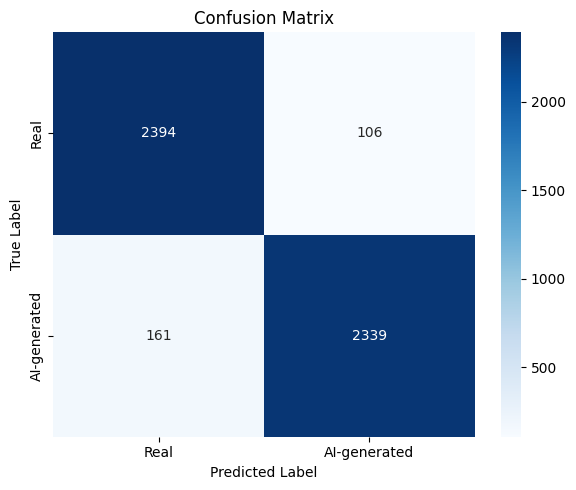

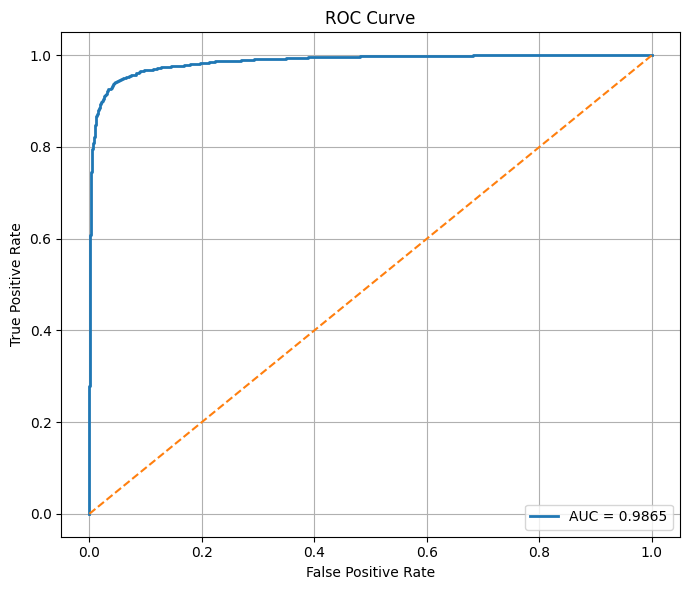

ROC-AUC: 0.9865
Test Loss: 0.14446426301625123
Test Acc : 0.9466
Test F1  : 0.9460060667340748
Roc auc score : 0.98652384


In [19]:
model.load_state_dict(
    torch.load("/kaggle/input/models/nishant2015/aidetector/pytorch/default/1/best_openfake_siglip50k.pth", map_location=device)
)

test_loss, test_acc, test_f1, roc_auc = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print("Test Loss:", test_loss)
print("Test Acc :", test_acc)
print("Test F1  :", test_f1)
print("Roc auc score :",roc_auc)

### Evaluation on an external AI image benchmark

To test generalisation, the trained OpenFake model is evaluated without further training on the separate AI Image Benchmark dataset. Images are collected recursively from the real and AI-generated folders and passed through the same SigLIP processor.

This cross-dataset test is more challenging because the image sources and generator distribution are not identical to OpenFake. Accuracy, precision, recall, F1-score, confusion matrix and ROC-AUC are calculated to show where performance changes on unseen data.


In [28]:
from pathlib import Path
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import torch
from tqdm import tqdm

REAL_DIR = Path("/kaggle/input/datasets/nishant2015/aiimagebenchmarkdataset/benchmark-v0.1/images/real")
FAKE_DIR = Path("/kaggle/input/datasets/nishant2015/aiimagebenchmarkdataset/benchmark-v0.1/images/ai")

def evaluate_ai_benchmark(
    model,
    processor,
    device,
    real_dir,
    fake_dir
):

    model.eval()

    image_paths = []
    labels = []

    for ext in ["*.jpg", "*.jpeg", "*.png", "*.webp"]:

        real_files = list(real_dir.rglob(ext))
        fake_files = list(fake_dir.rglob(ext))

        image_paths.extend(real_files)
        labels.extend([0] * len(real_files))

        image_paths.extend(fake_files)
        labels.extend([1] * len(fake_files))

    print("Total images:", len(image_paths))

    preds = []
    fake_probs = []

    with torch.no_grad():

        for img_path in tqdm(image_paths):

            try:
                image = Image.open(img_path).convert("RGB")

                inputs = processor(
                    images=image,
                    return_tensors="pt"
                )

                pixel_values = inputs["pixel_values"].to(device)

                logits = model(pixel_values)

                probs = torch.softmax(
                    logits,
                    dim=1
                )[0]

                fake_prob = probs[1].item()

                pred = torch.argmax(
                    probs,
                    dim=0
                ).item()

                preds.append(pred)
                fake_probs.append(fake_prob)

            except Exception:
                preds.append(1)
                fake_probs.append(1.0)

    acc = accuracy_score(labels, preds)

    precision = precision_score(
        labels,
        preds
    )

    recall = recall_score(
        labels,
        preds
    )

    f1 = f1_score(
        labels,
        preds
    )

    cm = confusion_matrix(
        labels,
        preds
    )

    fpr, tpr, thresholds = roc_curve(
        labels,
        fake_probs
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    print("\n")
    print("=" * 50)

    print("Accuracy :", acc)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)
    print("ROC-AUC  :", roc_auc)

    print("\nConfusion Matrix")
    print(cm)

    print("\nClassification Report")
    print(
        classification_report(
            labels,
            preds,
            target_names=[
                "Real",
                "AI-generated"
            ]
        )
    )


    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Real", "AI-generated"],
        yticklabels=["Real", "AI-generated"]
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix - AI Detector Arena Dataset")

    plt.tight_layout()
    plt.savefig(
        "ai_benchmark_confusion_matrix.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()


    plt.figure(figsize=(7, 6))

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"AUC = {roc_auc:.4f}"
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - AI Detector Arena Dataset")
    plt.legend(loc="lower right")
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(
        "ai_benchmark_roc_curve.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

    return acc, precision, recall, f1, roc_auc

Total images: 2038


100%|██████████| 2038/2038 [02:28<00:00, 13.70it/s]




Accuracy : 0.8253189401373896
Precision: 0.9265463917525774
Recall   : 0.706286836935167
F1 Score : 0.8015607580824972
ROC-AUC  : 0.9222649177549213

Confusion Matrix
[[963  57]
 [299 719]]

Classification Report
              precision    recall  f1-score   support

        Real       0.76      0.94      0.84      1020
AI-generated       0.93      0.71      0.80      1018

    accuracy                           0.83      2038
   macro avg       0.84      0.83      0.82      2038
weighted avg       0.84      0.83      0.82      2038



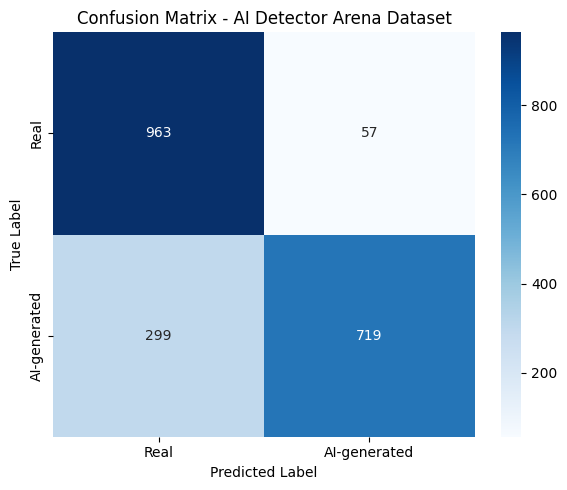

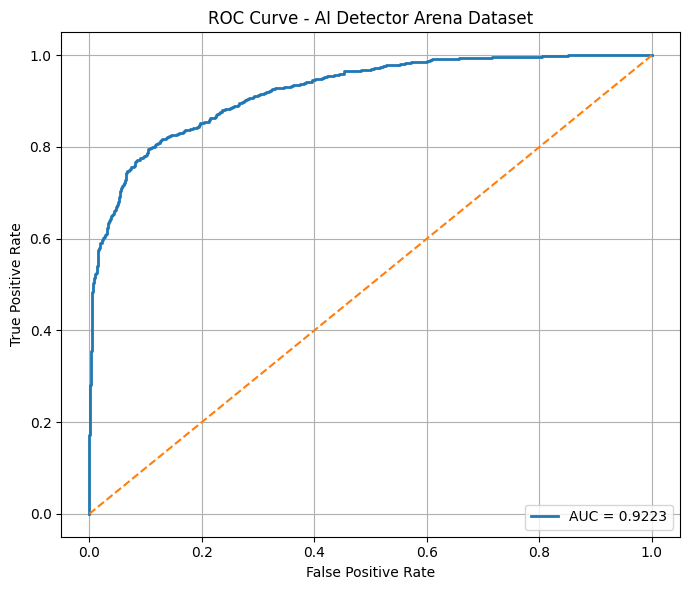

In [29]:
acc,  precision, recall, f1, roc_auc= evaluate_ai_benchmark(
    model,
    processor,
    device,
    REAL_DIR,
    FAKE_DIR
)

### Additional benchmark score

For comparison purposes, I also calculate a combined score using the observed F1-score, false-positive rate and false-negative rate. This is a custom summary measure rather than a standard classification metric, so the individual evaluation metrics are still reported separately.


In [22]:
TN = 963
FP = 57
FN = 299
TP = 719

f1 = 0.8015607580824972

fpr = FP / (FP + TN)
fnr = FN / (FN + TP)

combined_score = (
    0.5 * f1 +
    0.3 * (1 - fpr) +
    0.2 * (1 - fnr)
)

print(f"FPR: {fpr:.4f}")
print(f"FNR: {fnr:.4f}")
print(f"Combined Score: {combined_score:.4f}")
print(f"Combined Score (%): {combined_score * 100:.2f}%")

FPR: 0.0559
FNR: 0.2937
Combined Score: 0.8253
Combined Score (%): 82.53%


### Performance by image generator

The overall benchmark result can hide differences between individual AI generators. I therefore group the AI-generated benchmark images by generator name and evaluate the detector for each group.

This helps identify generators for which the detector transfers well and generators that are more difficult. The same real-image set is used alongside each generator group so that the resulting classification metrics can be compared in a consistent way.


In [23]:
from pathlib import Path
from PIL import Image
from collections import defaultdict

import torch
from tqdm import tqdm
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

import matplotlib.pyplot as plt
import seaborn as sns


REAL_DIR = Path("/kaggle/input/datasets/nishant2015/aiimagebenchmarkdataset/benchmark-v0.1/images/real")
FAKE_DIR = Path("/kaggle/input/datasets/nishant2015/aiimagebenchmarkdataset/benchmark-v0.1/images/ai")


def extract_generator_name(img_path):
    """
    Example:
    flux_2_flex_landscape_01.png -> flux_2_flex
    flux_pro_v1.1_landscape_01.png -> flux_pro_v1.1
    """

    name = img_path.stem

    parts = name.split("_")

    if len(parts) > 2:
        return "_".join(parts[:-2])

    return "unknown"


def predict_single_image(model, processor, device, img_path):
    image = Image.open(img_path).convert("RGB")

    inputs = processor(
        images=image,
        return_tensors="pt"
    )

    pixel_values = inputs["pixel_values"].to(device)

    logits = model(pixel_values)

    probs = torch.softmax(logits, dim=1)[0]

    fake_prob = probs[1].item()
    pred = torch.argmax(probs, dim=0).item()

    return pred, fake_prob


def evaluate_by_generator(
    model,
    processor,
    device,
    real_dir,
    fake_dir
):
    model.eval()

    exts = ["*.jpg", "*.jpeg", "*.png", "*.webp"]

    real_paths = []
    fake_paths = []

    for ext in exts:
        real_paths.extend(real_dir.rglob(ext))
        fake_paths.extend(fake_dir.rglob(ext))

    print("Real images:", len(real_paths))
    print("Fake images:", len(fake_paths))
    print("Total images:", len(real_paths) + len(fake_paths))

    all_labels = []
    all_preds = []
    all_fake_probs = []

    generator_results = defaultdict(lambda: {
        "labels": [],
        "preds": [],
        "fake_probs": []
    })

    with torch.no_grad():

        for img_path in tqdm(real_paths, desc="Evaluating real images"):
            try:
                pred, fake_prob = predict_single_image(
                    model,
                    processor,
                    device,
                    img_path
                )
            except Exception:
                pred = 1
                fake_prob = 1.0

            all_labels.append(0)
            all_preds.append(pred)
            all_fake_probs.append(fake_prob)

        for img_path in tqdm(fake_paths, desc="Evaluating fake images"):
            try:
                pred, fake_prob = predict_single_image(
                    model,
                    processor,
                    device,
                    img_path
                )
            except Exception:
                pred = 1
                fake_prob = 1.0

            generator = extract_generator_name(img_path)

            all_labels.append(1)
            all_preds.append(pred)
            all_fake_probs.append(fake_prob)

            generator_results[generator]["labels"].append(1)
            generator_results[generator]["preds"].append(pred)
            generator_results[generator]["fake_probs"].append(fake_prob)


    overall_acc = accuracy_score(all_labels, all_preds)
    overall_precision = precision_score(all_labels, all_preds, zero_division=0)
    overall_recall = recall_score(all_labels, all_preds, zero_division=0)
    overall_f1 = f1_score(all_labels, all_preds, zero_division=0)

    fpr, tpr, thresholds = roc_curve(all_labels, all_fake_probs)
    overall_auc = auc(fpr, tpr)

    overall_cm = confusion_matrix(all_labels, all_preds)

    print("\n")
    print("=" * 60)
    print("OVERALL RESULTS")
    print("=" * 60)
    print("Accuracy :", overall_acc)
    print("Precision:", overall_precision)
    print("Recall   :", overall_recall)
    print("F1 Score :", overall_f1)
    print("ROC-AUC  :", overall_auc)

    print("\nConfusion Matrix")
    print(overall_cm)

    print("\nClassification Report")
    print(
        classification_report(
            all_labels,
            all_preds,
            target_names=["Real", "Fake"],
            zero_division=0
        )
    )


    rows = []

    for generator, data in generator_results.items():

        labels = data["labels"]
        preds = data["preds"]
        probs = data["fake_probs"]

        total = len(labels)

        detected_fake = sum(
            1 for p in preds if p == 1
        )

        missed_fake = sum(
            1 for p in preds if p == 0
        )

        recall = recall_score(
            labels,
            preds,
            zero_division=0
        )

        avg_fake_prob = sum(probs) / len(probs)

        rows.append({
            "generator": generator,
            "total_fake_images": total,
            "detected_as_fake": detected_fake,
            "missed_as_real": missed_fake,
            "fake_recall": recall,
            "average_fake_probability": avg_fake_prob
        })

    generator_df = pd.DataFrame(rows)

    generator_df = generator_df.sort_values(
        by="fake_recall",
        ascending=False
    )

    print("\n")
    print("=" * 60)
    print("PER-GENERATOR RESULTS")
    print("=" * 60)

    print(generator_df)

    generator_df.to_csv(
        "per_generator_results.csv",
        index=False
    )


    plt.figure(figsize=(12, 6))

    sns.barplot(
        data=generator_df,
        x="generator",
        y="fake_recall"
    )

    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, 1)
    plt.ylabel("Fake Recall")
    plt.xlabel("AI Generator")
    plt.title("Fake Detection Recall by AI Generator")

    plt.tight_layout()
    plt.savefig(
        "per_generator_fake_recall.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

    return {
        "overall": {
            "accuracy": overall_acc,
            "precision": overall_precision,
            "recall": overall_recall,
            "f1": overall_f1,
            "roc_auc": overall_auc,
            "confusion_matrix": overall_cm
        },
        "per_generator": generator_df
    }

Real images: 1020
Fake images: 1018
Total images: 2038


Evaluating fake images: 100%|██████████| 1018/1018 [00:54<00:00, 18.65it/s]




OVERALL RESULTS
Accuracy : 0.8253189401373896
Precision: 0.9265463917525774
Recall   : 0.706286836935167
F1 Score : 0.8015607580824972
ROC-AUC  : 0.9222649177549213

Confusion Matrix
[[963  57]
 [299 719]]

Classification Report
              precision    recall  f1-score   support

        Real       0.76      0.94      0.84      1020
        Fake       0.93      0.71      0.80      1018

    accuracy                           0.83      2038
   macro avg       0.84      0.83      0.82      2038
weighted avg       0.84      0.83      0.82      2038



PER-GENERATOR RESULTS
           generator  total_fake_images  detected_as_fake  missed_as_real  \
8          glm_image                 60                50              10   
11       flux_2_flex                 60                50              10   
9      flux_pro_v1.1                 60                50              10   
15          wan_v2.6                 60                48              12   
13     gpt_image_1.5             

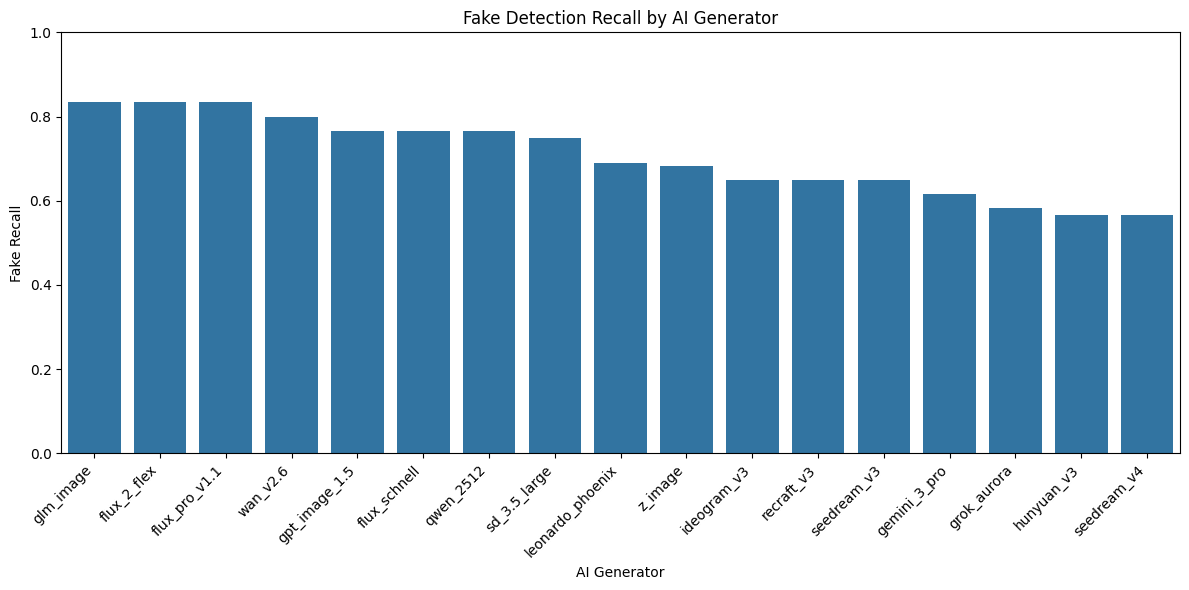

In [24]:
results = evaluate_by_generator(
    model=model,
    processor=processor,
    device=device,
    real_dir=REAL_DIR,
    fake_dir=FAKE_DIR
)

In [25]:
results["per_generator"]

,generator,total_fake_images,detected_as_fake,missed_as_real,fake_recall,average_fake_probability
8,glm_image,60,50,10,0.833333,0.818655
11,flux_2_flex,60,50,10,0.833333,0.822137
9,flux_pro_v1.1,60,50,10,0.833333,0.822989
15,wan_v2.6,60,48,12,0.800000,0.793632
13,gpt_image_1.5,60,46,14,0.766667,0.779790
7,flux_schnell,60,46,14,0.766667,0.737365
1,qwen_2512,60,46,14,0.766667,0.738098
16,sd_3.5_large,60,45,15,0.750000,0.714063
10,leonardo_phoenix,58,40,18,0.689655,0.693837
6,z_image,60,41,19,0.683333,0.652796


## Prompt analysis

The OpenFake metadata also contains the text prompts used for many AI-generated images. As a small exploratory analysis, I examine the most frequent prompt terms using a word cloud and a frequency plot. Common generic words such as *image*, *photo* and *realistic* are removed so that more informative content words are easier to see.

This analysis is descriptive and is not used as an input to the image classifier.


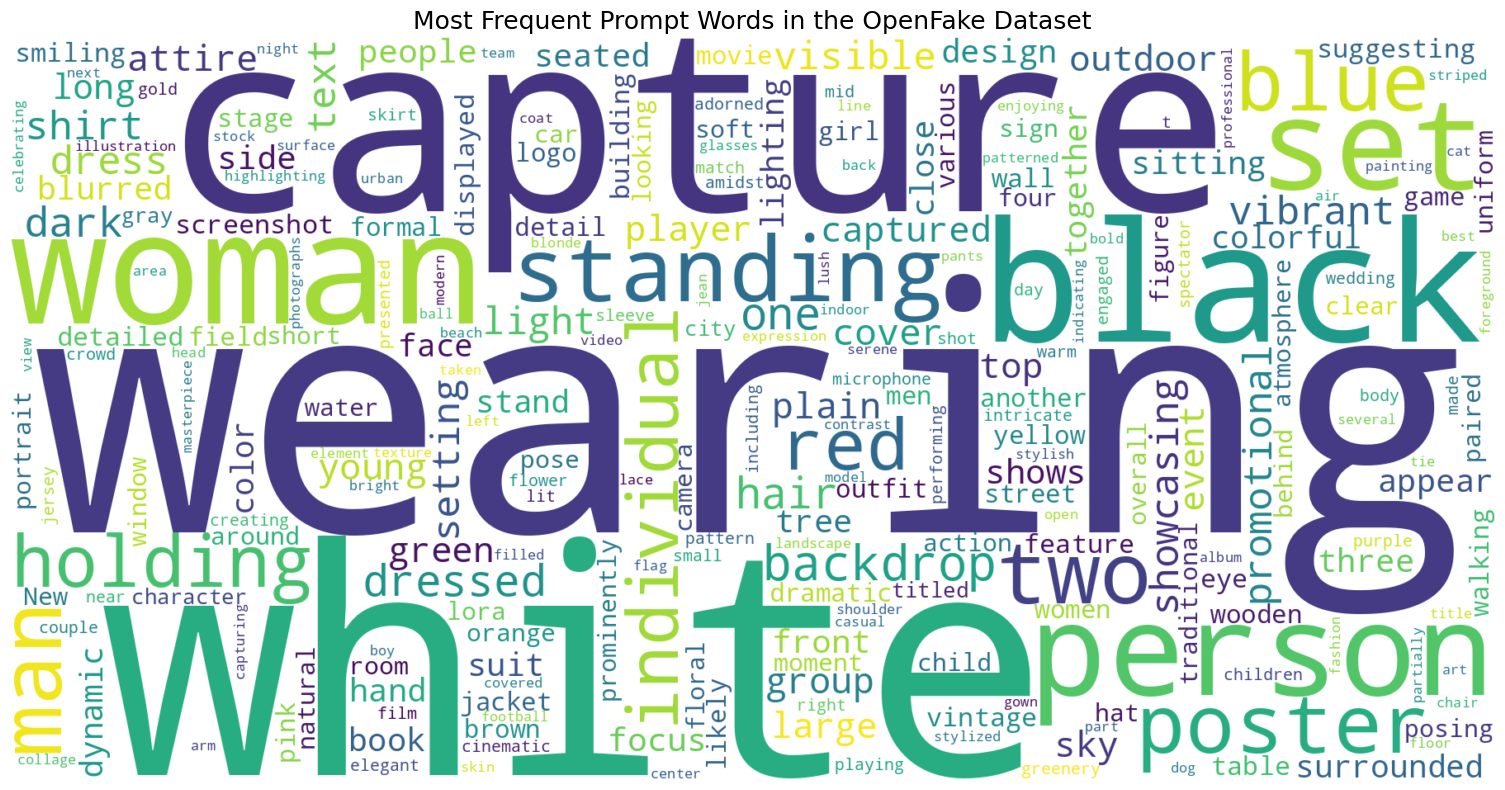

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

df = pd.read_csv(
    "/kaggle/input/datasets/nishant2015/openfake50k/kaggle/working/openfake_subset/metadata.csv"
)

fake_df = df[df["label"] == "fake"]

text = " ".join(
    fake_df["prompt"]
    .fillna("")
    .astype(str)
)

stopwords = set(STOPWORDS)

stopwords.update([
    "image",
    "photo",
    "photograph",
    "generate",
    "generated",
    "showing",
    "show",
    "depicting",
    "depicts",
    "featuring",
    "featuring",
    "high",
    "quality",
    "realistic",
    "background",
    "scene",
    "style"
])

wordcloud = WordCloud(
    width=1800,
    height=900,
    background_color="white",
    stopwords=stopwords,
    max_words=250,
    collocations=False
).generate(text)

plt.figure(figsize=(16,8))

plt.imshow(wordcloud, interpolation="bilinear")

plt.axis("off")

plt.title(
    "Most Frequent Prompt Words in the OpenFake Dataset",
    fontsize=18
)

plt.tight_layout()

plt.savefig(
    "openfake_prompt_wordcloud.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['aren', 'couldn', 'didn', 'doesn', 'don', 'hadn', 'hasn', 'haven', 'isn', 'let', 'll', 'mustn', 're', 'shan', 'shouldn', 've', 'wasn', 'weren', 'won', 'wouldn'] not in stop_words.
  warnings.warn(


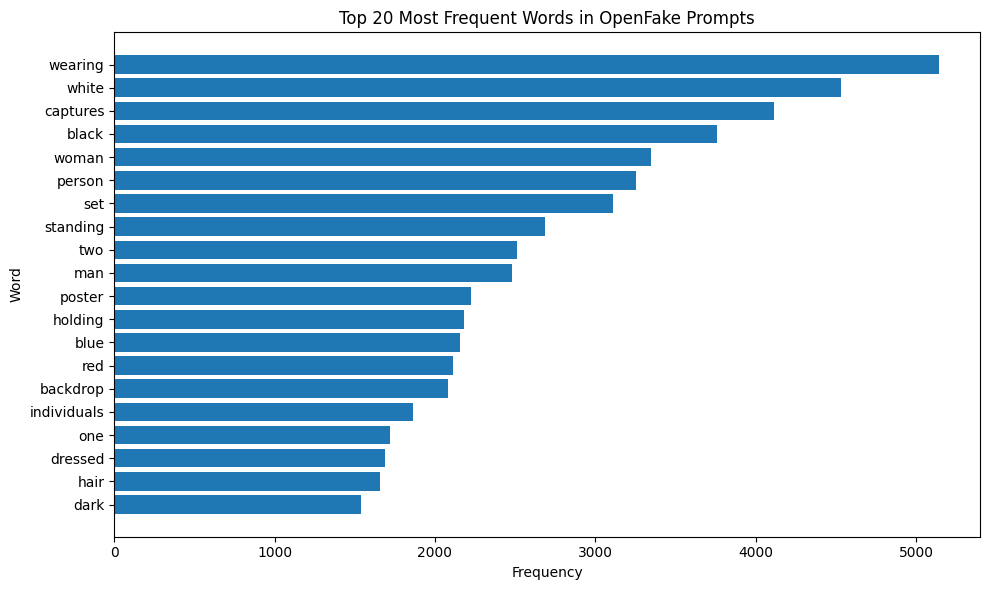

           Word  Count
17      wearing   5139
18        white   4532
3      captures   4113
1         black   3758
19        woman   3343
11       person   3251
14          set   3110
15     standing   2684
16          two   2509
9           man   2481
12       poster   2227
7       holding   2178
2          blue   2154
13          red   2114
0      backdrop   2083
8   individuals   1861
10          one   1717
5       dressed   1689
6          hair   1655
4          dark   1541


In [27]:
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import STOPWORDS
import pandas as pd
import matplotlib.pyplot as plt

custom_stopwords = set(STOPWORDS)

custom_stopwords.update([
    "image",
    "photo",
    "photograph",
    "generate",
    "generated",
    "showing",
    "show",
    "depicting",
    "depicts",
    "featuring",
    "high",
    "quality",
    "realistic",
    "background",
    "scene",
    "style"
])

vectorizer = CountVectorizer(
    stop_words=list(custom_stopwords),
    max_features=20
)

X = vectorizer.fit_transform(
    fake_df["prompt"].fillna("")
)

counts = X.sum(axis=0).A1
words = vectorizer.get_feature_names_out()

freq = (
    pd.DataFrame({
        "Word": words,
        "Count": counts
    })
    .sort_values(by="Count", ascending=False)
)

plt.figure(figsize=(10,6))

plt.barh(freq["Word"], freq["Count"])

plt.gca().invert_yaxis()

plt.xlabel("Frequency")
plt.ylabel("Word")
plt.title("Top 20 Most Frequent Words in OpenFake Prompts")

plt.tight_layout()

plt.savefig(
    "prompt_frequency.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(freq)